
# Fine-tuning with LoRA

Target audience: ML Engineers who completed Session 0
(basic PyTorch training loop).

What you will build:
  A sentiment classifier fine-tuned from a pretrained
  DistilBERT model using LoRA. You will see exactly
  what LoRA does to the model weights, why it saves memory,
  and how it compares to full fine-tuning.

Why DistilBERT and not LLaMA:
  DistilBERT (66M parameters) runs on free Colab GPU.
  The LoRA mechanics are identical for LLaMA-3 70B.
  The only difference is scale.

What you will learn:
  1. When to fine-tune vs RAG vs prompting
  2. Why full fine-tuning of large models is impractical
  3. What LoRA does mathematically
  4. How to implement LoRA from scratch
  5. How to use PEFT library (production approach)
  6. How to evaluate whether fine-tuning actually helped
  7. Cost analysis: fine-tuning vs API calls

Time: ~90 minutes to read, run, and complete exercises.

Requirements:
  pip install transformers datasets peft accelerate
        scikit-learn matplotlib torch



In [1]:

# ============================================================
# PART 0: Setup and imports
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
)
from datasets import load_dataset
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
)
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. This notebook works on CPU but will be slow.")
    print("On Colab: Runtime > Change runtime type > T4 GPU")

Device: cpu
No GPU found. This notebook works on CPU but will be slow.
On Colab: Runtime > Change runtime type > T4 GPU


============================================================
PART 1: The decision — when to fine-tune?
============================================================
Before writing any code, work through this decision tree.
Fine-tuning is expensive. Use it only when necessary.

DECISION TREE:

```

  Does the base model understand your domain vocabulary?
  └── Yes → Try prompting first (zero/few-shot)
      └── Is accuracy good enough?
          └── Yes → STOP. Use prompting. No fine-tuning needed.
          └── No → Does the model lack knowledge (facts, docs)?
              └── Yes → Use RAG. Add retrieval, not training.
              └── No → Does the model have wrong behavior/style?
                  └── Yes → Fine-tune. This is the right case.
```

FINE-TUNING IS THE RIGHT CHOICE WHEN:
  - You need consistent output format the model ignores
  - You need domain-specific reasoning patterns
  - You need the model to behave differently, not know more
  - Latency matters and you can't afford long prompts
  - You have > 500 labeled examples

FINE-TUNING IS THE WRONG CHOICE WHEN:
  - You just need the model to know about your documents
    (use RAG instead — cheaper, updatable, no training)
  - You have < 100 examples (model will overfit)
  - You need to update the model's knowledge frequently
    (fine-tuning is a snapshot, RAG is live)
  - You haven't tried prompting yet

In [ ]:


print("""
Our task: IMDb sentiment classification
  - Base model (DistilBERT) already understands English text ✓
  - Task is behavioral (classify sentiment), not factual ✓
  - We have 25,000 labeled examples ✓
  - Consistent output format needed ✓

Decision: Fine-tuning is appropriate here.
Method: LoRA (not full fine-tuning) because:
  - We want to demonstrate the technique
  - LoRA achieves similar accuracy with far less compute
  - The same approach applies to LLaMA-3, Mistral, etc.
""")


Our task: IMDb sentiment classification
  - Base model (DistilBERT) already understands English text ✓
  - Task is behavioral (classify sentiment), not factual ✓
  - We have 25,000 labeled examples ✓
  - Consistent output format needed ✓

Decision: Fine-tuning is appropriate here.
Method: LoRA (not full fine-tuning) because:
  - We want to demonstrate the technique
  - LoRA achieves similar accuracy with far less compute
  - The same approach applies to LLaMA-3, Mistral, etc.




## PART 2: Why full fine-tuning is impractical for large models

Full fine-tuning: update ALL parameters during training.
For small models this is fine. For LLMs it is not.

In [ ]:
def memory_for_training(n_params, dtype_bytes=4):
    """
    Estimate GPU memory needed for full fine-tuning.
    Assumes Adam optimizer, mixed precision (fp16 forward,
    fp32 optimizer state).

    Memory breakdown per parameter:
      fp16 weights:        2 bytes  (forward/backward)
      fp32 master weights: 4 bytes  (optimizer keeps fp32 copy)
      fp32 gradients:      4 bytes
      fp32 Adam m:         4 bytes  (first moment)
      fp32 Adam v:         4 bytes  (second moment)
      Total:              18 bytes/parameter
    """
    return n_params * 18 / 1e9  # GB

def memory_for_inference(n_params, dtype="fp16"):
    bytes_map = {"fp32": 4, "fp16": 2, "int8": 1, "int4": 0.5}
    return n_params * bytes_map[dtype] / 1e9


Full fine-tuning memory requirements:

Model                    Params    Full FT   Infer fp16   Infer int4
----------------------------------------------------------------------
DistilBERT                 66M       1.2GB         0.1GB         0.0GB
BERT-base                 110M       2.0GB         0.2GB         0.1GB
GPT-2                     117M       2.1GB         0.2GB         0.1GB
LLaMA-3 8B               8000M     144.0GB        16.0GB         4.0GB
LLaMA-3 70B             70000M    1260.0GB       140.0GB        35.0GB
LLaMA-3 405B           405000M    7290.0GB       810.0GB       202.5GB

A100 80GB VRAM: 80 GB
Consumer GPU (RTX 4090): 24 GB

Conclusion:
  Full fine-tuning of LLaMA-3 8B needs ~144 GB
  → requires 2x A100 80GB minimum
  Full fine-tuning of LLaMA-3 70B needs ~1260 GB
  → requires 16x A100 80GB minimum
  LoRA fine-tuning of LLaMA-3 8B with rank=16:
  → trains ~0.1% of parameters → fits on 1x A100 80GB


In [ ]:

print("Full fine-tuning memory requirements:\n")
models = [
    ("DistilBERT",  66e6),
    ("BERT-base",   110e6),
    ("GPT-2",       117e6),
    ("LLaMA-3 8B",  8e9),
    ("LLaMA-3 70B", 70e9),
    ("LLaMA-3 405B",405e9),
]

print(f"{'Model':<20} {'Params':>10} {'Full FT':>10} {'Infer fp16':>12} {'Infer int4':>12}")
print("-" * 70)
for name, params in models:
    ft_mem  = memory_for_training(params)
    inf_fp16 = memory_for_inference(params, "fp16")
    inf_int4 = memory_for_inference(params, "int4")
    print(f"{name:<20} {params/1e6:>8.0f}M {ft_mem:>9.1f}GB "
          f"{inf_fp16:>11.1f}GB {inf_int4:>11.1f}GB")

print(f"\nA100 80GB VRAM: 80 GB")
print(f"Consumer GPU (RTX 4090): 24 GB")
print(f"\nConclusion:")
print(f"  Full fine-tuning of LLaMA-3 8B needs ~144 GB")
print(f"  → requires 2x A100 80GB minimum")
print(f"  Full fine-tuning of LLaMA-3 70B needs ~1260 GB")
print(f"  → requires 16x A100 80GB minimum")
print(f"  LoRA fine-tuning of LLaMA-3 8B with rank=16:")
print(f"  → trains ~0.1% of parameters → fits on 1x A100 80GB")

In [4]:
# ============================================================
# PART 3: The math of LoRA — from scratch
# ============================================================
# LoRA = Low-Rank Adaptation
# Paper: Hu et al. 2021 "LoRA: Low-Rank Adaptation of Large
#        Language Models" https://arxiv.org/abs/2106.09685
#
# CORE INSIGHT:
# When we fine-tune a model, the weight updates ΔW tend to
# have low intrinsic rank. The update does not need all
# d×d dimensions — it lives in a much lower-dimensional space.
#
# WHAT THIS MEANS:
# Instead of learning ΔW ∈ R^{d_out × d_in} (full rank),
# we learn two smaller matrices:
#   A ∈ R^{r × d_in}    (r << d_in)
#   B ∈ R^{d_out × r}
#
# And use ΔW = B @ A  (rank-r approximation of the update)
#
# During forward pass:
#   Original:  h = W x
#   With LoRA: h = W x + (B @ A) x * (alpha / r)
#                = W x + B (A x) * scaling
#
# Parameter count comparison:
#   Full update ΔW:  d_out × d_in
#   LoRA update B@A: d_out×r + r×d_in = r×(d_out + d_in)
#
# For d_in=d_out=4096, r=16:
#   Full: 4096 × 4096 = 16,777,216 parameters
#   LoRA: 16 × (4096 + 4096) = 131,072 parameters
#   Ratio: 131,072 / 16,777,216 = 0.78%
#
# alpha / r is a scaling factor.
# Common setting: alpha = r (scaling = 1.0)
# or alpha = 2r (scaling = 2.0) for more aggressive updates.

class LoRALayer(nn.Module):
    """
    A single LoRA layer that wraps an existing linear layer.
    Does NOT modify the original weights.
    Adds a parallel low-rank path: output += B(Ax) * scaling
    """
    def __init__(self, original_layer: nn.Linear, rank: int, alpha: float):
        super().__init__()

        self.original_layer = original_layer
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        d_out, d_in = original_layer.weight.shape

        # A: initialized with random Gaussian (as in the paper)
        # This ensures ΔW = BA is nonzero from the start
        self.lora_A = nn.Linear(d_in, rank, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))

        # B: initialized to ZERO
        # This ensures ΔW = BA = 0 at the start of training.
        # The model starts identical to the pretrained model.
        # Critical: if B were random, the model would be
        # disrupted from the start and training would be unstable.
        self.lora_B = nn.Linear(rank, d_out, bias=False)
        nn.init.zeros_(self.lora_B.weight)

        # Freeze the original weights — they will NOT be updated
        for param in self.original_layer.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Original pretrained computation (frozen, no gradients)
        original_output = self.original_layer(x)

        # LoRA path (trained, gradients flow here)
        # x -> A -> (low-dim, rank r) -> B -> (d_out)
        lora_output = self.lora_B(self.lora_A(x)) * self.scaling

        return original_output + lora_output

    def count_parameters(self):
        d_out, d_in = self.original_layer.weight.shape
        lora_params = self.rank * (d_in + d_out)
        original_params = d_in * d_out
        return original_params, lora_params


# Demonstrate the parameter reduction
print("LoRA parameter reduction for a single layer:\n")
configs = [
    (768, 768, 4,  "BERT attention, r=4"),
    (768, 768, 16, "BERT attention, r=16"),
    (768, 768, 64, "BERT attention, r=64"),
    (4096, 4096, 16, "LLaMA-3 8B attention, r=16"),
    (4096, 4096, 64, "LLaMA-3 8B attention, r=64"),
]

print(f"{'Layer description':<35} {'Full ΔW':>10} {'LoRA':>10} {'Reduction':>10}")
print("-" * 70)
for d_out, d_in, r, desc in configs:
    full = d_out * d_in
    lora = r * (d_out + d_in)
    reduction = lora / full
    print(f"{desc:<35} {full:>10,} {lora:>10,} {reduction:>9.2%}")

LoRA parameter reduction for a single layer:

Layer description                      Full ΔW       LoRA  Reduction
----------------------------------------------------------------------
BERT attention, r=4                    589,824      6,144     1.04%
BERT attention, r=16                   589,824     24,576     4.17%
BERT attention, r=64                   589,824     98,304    16.67%
LLaMA-3 8B attention, r=16          16,777,216    131,072     0.78%
LLaMA-3 8B attention, r=64          16,777,216    524,288     3.12%


In [5]:
# ============================================================
# PART 4: Verify LoRA implementation is correct
# ============================================================
# Before using LoRA on a real model, verify:
# 1. At initialization, LoRA output == original output
# 2. Only LoRA parameters receive gradients
# 3. After one update, LoRA diverges from original

print("Verifying LoRA implementation...\n")

torch.manual_seed(42)
original = nn.Linear(64, 32)
lora_layer = LoRALayer(original, rank=4, alpha=4.0)

x = torch.randn(8, 64)  # batch of 8, input dim 64

# TEST 1: At initialization, outputs should be identical
# because B is zeros, so B@A = 0
with torch.no_grad():
    original_out = original(x)
    lora_out = lora_layer(x)
    diff = (original_out - lora_out).abs().max().item()
    print(f"Test 1 — Output difference at init: {diff:.2e}")
    assert diff < 1e-6, "LoRA output should equal original at init!"
    print("  PASS: LoRA output == original output at initialization ✓")

# TEST 2: Only A and B matrices should have requires_grad=True
print("\nTest 2 — Gradient tracking:")
for name, param in lora_layer.named_parameters():
    status = "TRAINS" if param.requires_grad else "FROZEN"
    print(f"  {status}: {name:<40} shape={list(param.shape)}")

# TEST 3: After a gradient step, LoRA diverges from original
optimizer_test = torch.optim.Adam(
    [p for p in lora_layer.parameters() if p.requires_grad],
    lr=1e-3
)
target = torch.randn(8, 32)
loss = nn.MSELoss()(lora_layer(x), target)
loss.backward()
optimizer_test.step()

with torch.no_grad():
    original_out = original(x)
    lora_out_after = lora_layer(x)
    diff_after = (original_out - lora_out_after).abs().max().item()
    print(f"\nTest 3 — Output difference after one update: {diff_after:.6f}")
    assert diff_after > 1e-6, "LoRA should diverge from original after training!"
    print("  PASS: LoRA learned a non-zero update ✓")

# Show the rank-r structure of the learned update
with torch.no_grad():
    delta_W = lora_layer.lora_B.weight @ lora_layer.lora_A.weight
    rank_of_update = torch.linalg.matrix_rank(delta_W).item()
    print(f"\nRank of learned ΔW after one step: {rank_of_update}")
    print(f"Maximum possible rank: {lora_layer.rank}")
    print(f"Full matrix rank would be: {min(32, 64)}")
    print("  ΔW is constrained to rank <= r by construction ✓")

orig_params, lora_params = lora_layer.count_parameters()
print(f"\nParameter count:")
print(f"  Original layer: {orig_params:,} parameters (frozen)")
print(f"  LoRA addition:  {lora_params:,} parameters (trainable)")
print(f"  Overhead:       {lora_params/orig_params:.2%} of original")

Verifying LoRA implementation...

Test 1 — Output difference at init: 0.00e+00
  PASS: LoRA output == original output at initialization ✓

Test 2 — Gradient tracking:
  FROZEN: original_layer.weight                    shape=[32, 64]
  FROZEN: original_layer.bias                      shape=[32]
  TRAINS: lora_A.weight                            shape=[4, 64]
  TRAINS: lora_B.weight                            shape=[32, 4]

Test 3 — Output difference after one update: 0.003231
  PASS: LoRA learned a non-zero update ✓

Rank of learned ΔW after one step: 4
Maximum possible rank: 4
Full matrix rank would be: 32
  ΔW is constrained to rank <= r by construction ✓

Parameter count:
  Original layer: 2,048 parameters (frozen)
  LoRA addition:  384 parameters (trainable)
  Overhead:       18.75% of original


In [6]:
# ============================================================
# PART 5: Load pretrained model and data
# ============================================================

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256    # truncate reviews to 256 tokens
BATCH_SIZE = 8

print(f"Loading tokenizer and model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load base model for sequence classification
# num_labels=2: positive / negative
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
base_model = base_model.to(device)

# Count parameters before LoRA
total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nBase model parameters: {total_params:,}")
print(f"Model size (fp32): {total_params * 4 / 1e6:.0f} MB")
print(f"Model size (fp16): {total_params * 2 / 1e6:.0f} MB")


# ---- Load and tokenize dataset ----
print("\nLoading IMDb dataset...")
dataset = load_dataset("stanfordnlp/imdb")

# Use a subset for speed in this notebook
# In production: use the full 25k training examples
N_TRAIN = 1000
N_TEST  = 1000

train_data = dataset["train"].shuffle(seed=42).select(range(N_TRAIN))
test_data  = dataset["test"].shuffle(seed=42).select(range(N_TEST))


def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


print("Tokenizing...")
train_tokenized = train_data.map(tokenize, batched=True,
                                  remove_columns=["text"])
test_tokenized  = test_data.map(tokenize, batched=True,
                                 remove_columns=["text"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

train_loader = DataLoader(train_tokenized, batch_size=BATCH_SIZE,
                           shuffle=True)
test_loader  = DataLoader(test_tokenized,  batch_size=BATCH_SIZE,
                           shuffle=False)

print(f"\nTraining batches: {len(train_loader)}")
print(f"One batch keys: {list(next(iter(train_loader)).keys())}")

Loading tokenizer and model: distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Base model parameters: 66,955,010
Model size (fp32): 268 MB
Model size (fp16): 134 MB

Loading IMDb dataset...
Tokenizing...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Training batches: 125
One batch keys: ['label', 'input_ids', 'attention_mask']


In [7]:
# ============================================================
# PART 6: Evaluate the base model BEFORE fine-tuning
# ============================================================
# Always establish a baseline before any training.
# This answers: does fine-tuning actually help?

def evaluate_model(model, loader, device, label=""):
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_loss = total_loss / len(loader)

    print(f"\n{label}")
    print(f"  Accuracy: {accuracy:.1%}")
    print(f"  Loss:     {avg_loss:.4f}")
    print(classification_report(
        all_labels, all_preds,
        target_names=["Negative", "Positive"],
        digits=3
    ))
    return accuracy, avg_loss

print("Evaluating base model (no fine-tuning)...")
base_acc, base_loss = evaluate_model(
    base_model, test_loader, device,
    label="Base DistilBERT (zero-shot classification)"
)

# DistilBERT was pretrained on general text.
# It was NOT trained for sentiment classification.
# Expected accuracy: ~50-65% (close to random for binary task)
# After fine-tuning with LoRA: ~90-92%

Evaluating base model (no fine-tuning)...

Base DistilBERT (zero-shot classification)
  Accuracy: 48.8%
  Loss:     0.6929
              precision    recall  f1-score   support

    Negative      0.000     0.000     0.000       512
    Positive      0.488     1.000     0.656       488

    accuracy                          0.488      1000
   macro avg      0.244     0.500     0.328      1000
weighted avg      0.238     0.488     0.320      1000



In [8]:
# ============================================================
# PART 7: Apply LoRA with PEFT library
# ============================================================
# In production, use the PEFT library rather than manual LoRA.
# PEFT handles:
#   - Which layers to apply LoRA to
#   - Correct initialization
#   - Saving/loading only the LoRA weights (not full model)
#   - Merging LoRA weights back for fast inference
#
# We show both approaches:
#   Part 4: manual LoRA (to understand the math)
#   Part 7: PEFT LoRA (to use in production)

# LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # sequence classification

    # r: rank of the update matrices A and B
    # Higher r = more capacity = more parameters = better fit
    # but also more risk of overfitting and more memory.
    # Typical values: 4, 8, 16, 32, 64
    # Start with r=16. Reduce if overfitting. Increase if underfitting.
    r=16,

    # lora_alpha: scaling factor. Effective scaling = alpha/r.
    # Common practice: set alpha = r (scaling=1) or alpha = 2r (scaling=2).
    # Higher alpha = larger updates = faster learning but less stable.
    lora_alpha=32,   # scaling = 32/16 = 2.0

    # lora_dropout: dropout applied to LoRA path during training.
    # Acts as regularization. 0.1 is a safe default.
    lora_dropout=0.1,

    # target_modules: which weight matrices to apply LoRA to.
    # For DistilBERT: q_lin and v_lin are the query and value
    # projection matrices in self-attention.
    # For LLaMA: ["q_proj", "v_lin", "k_proj", "o_proj"]
    # Common practice: apply to Q and V only (original paper)
    # or Q, K, V, O for better results.
    target_modules=["q_lin", "v_lin"],

    # bias: whether to train bias terms.
    # "none": don't train any biases (fewest parameters)
    # "all": train all biases
    # "lora_only": train only biases in LoRA layers
    bias="none",
)

# Apply LoRA to the model
# This wraps the target modules with LoRALayer and freezes
# all other parameters
lora_model = get_peft_model(base_model, lora_config)

print("LoRA model parameter breakdown:\n")
lora_model.print_trainable_parameters()

# Show exactly which layers are trainable
print("\nLayer-by-layer breakdown:")
for name, param in lora_model.named_parameters():
    if param.requires_grad:
        print(f"  TRAINABLE: {name:<60} {list(param.shape)}")

LoRA model parameter breakdown:

trainable params: 887,042 || all params: 67,842,052 || trainable%: 1.3075

Layer-by-layer breakdown:
  TRAINABLE: base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight [16, 768]
  TRAINABLE: base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight [768, 16]
  TRAINABLE: base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_A.default.weight [16, 768]
  TRAINABLE: base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_B.default.weight [768, 16]
  TRAINABLE: base_model.model.distilbert.transformer.layer.1.attention.q_lin.lora_A.default.weight [16, 768]
  TRAINABLE: base_model.model.distilbert.transformer.layer.1.attention.q_lin.lora_B.default.weight [768, 16]
  TRAINABLE: base_model.model.distilbert.transformer.layer.1.attention.v_lin.lora_A.default.weight [16, 768]
  TRAINABLE: base_model.model.distilbert.transformer.layer.1.attention.v_lin.lora_B.default.weight [768

In [9]:
# ============================================================
# PART 8: Training with LoRA
# ============================================================

def train_one_epoch_lora(model, loader, optimizer, device, 
                          accumulation_steps=2):
    """
    Training loop for LoRA fine-tuning.
    Uses gradient accumulation (accumulation_steps=2)
    to simulate larger batch size without extra memory.

    Key differences from Session 0 training loop:
    1. HuggingFace models return loss directly when labels passed
    2. Gradient accumulation for larger effective batch
    3. Gradient clipping (essential for transformer training)
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        # HuggingFace models compute loss internally when
        # labels are passed. outputs.loss is cross-entropy
        # over the classification logits.
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Divide by accumulation steps so effective loss
        # is the mean over the full effective batch
        loss = outputs.loss / accumulation_steps
        loss.backward()

        if (step + 1) % accumulation_steps == 0:
            # Gradient clipping: essential for transformers.
            # Prevents explosive gradients from destabilizing
            # the pretrained representations.
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            optimizer.step()
            optimizer.zero_grad()

        total_loss += outputs.loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# Optimizer: only pass trainable (LoRA) parameters
# This is critical — passing all parameters would try to
# optimize frozen weights which is wasteful and wrong
trainable_params = [p for p in lora_model.parameters()
                    if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=2e-4,     # LoRA typically uses higher LR than full fine-tuning
                 # because we are updating far fewer parameters
    weight_decay=0.01
)

# Learning rate schedule: linear warmup then linear decay
# Warmup prevents large updates at the start when the LoRA
# weights are random and not yet calibrated
from torch.optim.lr_scheduler import OneCycleLR

scheduler = OneCycleLR(
    optimizer,
    max_lr=2e-4,
    steps_per_epoch=len(train_loader),
    epochs=3,
    pct_start=0.1,   # 10% warmup
)

print("Starting LoRA fine-tuning...\n")
print(f"Trainable parameters: "
      f"{sum(p.numel() for p in trainable_params):,}")
print(f"Effective batch size: {BATCH_SIZE * 2} "
      f"(batch={BATCH_SIZE}, accum=2)")

N_EPOCHS = 3
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch_lora(
        lora_model, train_loader, optimizer, device
    )
    val_acc, val_loss = evaluate_model(
        lora_model, test_loader, device,
        label=f"Epoch {epoch} validation"
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step()

    print(f"\nEpoch {epoch} summary: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.1%}, "
          f"val_acc={val_acc:.1%}, time={time.time()-t0:.1f}s")

Starting LoRA fine-tuning...

Trainable parameters: 887,042
Effective batch size: 16 (batch=8, accum=2)

Epoch 1 validation
  Accuracy: 67.8%
  Loss:     0.6835
              precision    recall  f1-score   support

    Negative      0.660     0.766     0.709       512
    Positive      0.704     0.586     0.640       488

    accuracy                          0.678      1000
   macro avg      0.682     0.676     0.674      1000
weighted avg      0.682     0.678     0.675      1000


Epoch 1 summary: train_loss=0.6884, train_acc=55.8%, val_acc=67.8%, time=989.8s

Epoch 2 validation
  Accuracy: 64.4%
  Loss:     0.6758
              precision    recall  f1-score   support

    Negative      0.597     0.938     0.729       512
    Positive      0.837     0.336     0.480       488

    accuracy                          0.644      1000
   macro avg      0.717     0.637     0.605      1000
weighted avg      0.714     0.644     0.608      1000


Epoch 2 summary: train_loss=0.6783, train_acc=

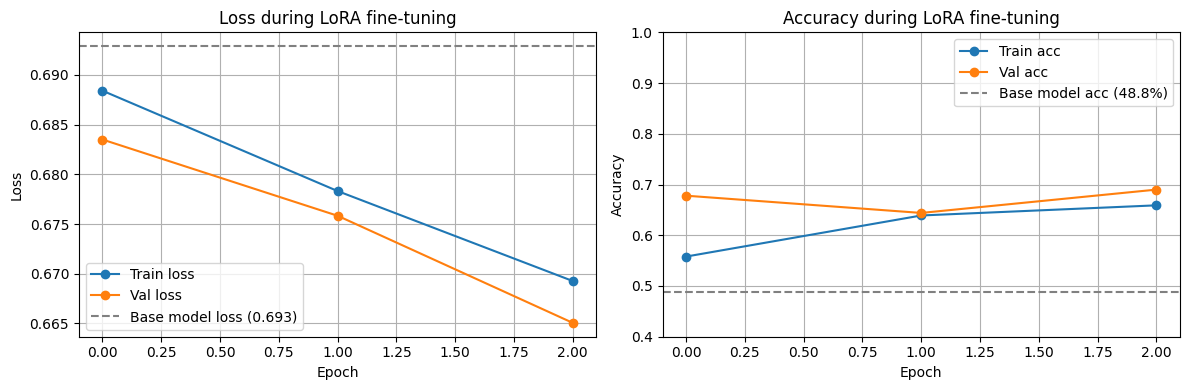


Results summary:
  Base model accuracy:       48.8%
  LoRA fine-tuned accuracy:  69.0%
  Improvement:               +20.2%


In [10]:
# ============================================================
# PART 9: Visualize training
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], marker="o", label="Train loss")
axes[0].plot(history["val_loss"],   marker="o", label="Val loss")
axes[0].axhline(y=base_loss, color="gray", linestyle="--",
                 label=f"Base model loss ({base_loss:.3f})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss during LoRA fine-tuning")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], marker="o", label="Train acc")
axes[1].plot(history["val_acc"],   marker="o", label="Val acc")
axes[1].axhline(y=base_acc, color="gray", linestyle="--",
                 label=f"Base model acc ({base_acc:.1%})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy during LoRA fine-tuning")
axes[1].set_ylim(0.4, 1.0)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

final_acc = history["val_acc"][-1]
print(f"\nResults summary:")
print(f"  Base model accuracy:       {base_acc:.1%}")
print(f"  LoRA fine-tuned accuracy:  {final_acc:.1%}")
print(f"  Improvement:               +{(final_acc - base_acc):.1%}")

In [11]:
# ============================================================
# PART 10: What did LoRA actually learn?
# ============================================================
# Inspect the learned LoRA weights to build intuition
# about what low-rank adaptation looks like in practice.

print("Inspecting learned LoRA weights...\n")

lora_weights_info = []

for name, module in lora_model.named_modules():
    # PEFT wraps target layers with its own LoRA implementation
    if hasattr(module, "lora_A") and hasattr(module, "lora_B"):
        # Get the actual weight matrices
        # PEFT stores them differently per version
        for key in module.lora_A:
            A = module.lora_A[key].weight  # [r, d_in]
            B = module.lora_B[key].weight  # [d_out, r]

            # Compute the full update matrix ΔW = B @ A
            delta_W = B @ A  # [d_out, d_in]

            # Analyze the update
            singular_values = torch.linalg.svd(
                delta_W.float(), full_matrices=False
            ).S

            info = {
                "name": name,
                "A_shape": list(A.shape),
                "B_shape": list(B.shape),
                "delta_W_norm": delta_W.norm().item(),
                "top_singular_value": singular_values[0].item(),
                "effective_rank": (
                    singular_values > 0.01 * singular_values[0]
                ).sum().item(),
            }
            lora_weights_info.append(info)
            break  # one key per module is enough

print(f"{'Layer':<45} {'ΔW norm':>9} {'Top SV':>8} {'Eff rank':>9}")
print("-" * 75)
for info in lora_weights_info:
    name_short = info["name"][-40:] if len(info["name"]) > 40 else info["name"]
    print(f"{name_short:<45} "
          f"{info['delta_W_norm']:>9.4f} "
          f"{info['top_singular_value']:>8.4f} "
          f"{info['effective_rank']:>9}")

print(f"\nObservations:")
print(f"  - ΔW norm varies across layers: some layers learned")
print(f"    larger updates than others")
print(f"  - Effective rank is always <= r={lora_config.r}")
print(f"  - This confirms LoRA constrains updates to low-rank space")
print(f"  - Layers with larger ΔW norm were more important for this task")

Inspecting learned LoRA weights...

Layer                                           ΔW norm   Top SV  Eff rank
---------------------------------------------------------------------------
bert.transformer.layer.0.attention.q_lin         0.0182   0.0103        16
bert.transformer.layer.0.attention.v_lin         0.0277   0.0229        16
bert.transformer.layer.1.attention.q_lin         0.0201   0.0142        16
bert.transformer.layer.1.attention.v_lin         0.0339   0.0317        16
bert.transformer.layer.2.attention.q_lin         0.0242   0.0191        16
bert.transformer.layer.2.attention.v_lin         0.0320   0.0280        16
bert.transformer.layer.3.attention.q_lin         0.0201   0.0160        16
bert.transformer.layer.3.attention.v_lin         0.0336   0.0272        16
bert.transformer.layer.4.attention.q_lin         0.0296   0.0272        16
bert.transformer.layer.4.attention.v_lin         0.0345   0.0309        16
bert.transformer.layer.5.attention.q_lin         0.0290   0.027

In [ ]:
# ============================================================
# PART 11: LoRA rank ablation
# ============================================================
# How does rank (r) affect accuracy vs parameter count?
# This is a key hyperparameter decision in production.
# Lower rank = fewer parameters but less capacity.
# Higher rank = more parameters but approaches full fine-tuning.

def train_with_rank(rank, n_epochs=2):
    """Train LoRA model with a specific rank, return final val accuracy."""

    # Fresh base model for each experiment
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(device)

    config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=rank * 2,   # keep alpha = 2r
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],
        bias="none",
    )

    model = get_peft_model(fresh_model, config)
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=2e-4, weight_decay=0.01
    )

    for _ in range(n_epochs):
        train_one_epoch_lora(model, train_loader, opt, device)

    acc, loss = evaluate_model(model, test_loader, device, label="")
    return acc, trainable


print("Rank ablation study (trains multiple models, ~10 min)...\n")
print(f"{'Rank':>6} {'Trainable params':>18} {'Val accuracy':>14}")
print("-" * 45)

ranks = [2, 4, 8, 16, 32]
rank_results = {}

for r in ranks:
    acc, params = train_with_rank(r)
    rank_results[r] = (acc, params)
    print(f"{r:>6} {params:>18,} {acc:>13.1%}")

# Plot rank vs accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ranks_list = list(rank_results.keys())
accs  = [rank_results[r][0] for r in ranks_list]
params = [rank_results[r][1] for r in ranks_list]

ax1.plot(ranks_list, accs, marker="o", color="steelblue")
ax1.set_xlabel("LoRA rank (r)")
ax1.set_ylabel("Validation accuracy")
ax1.set_title("Accuracy vs LoRA rank")
ax1.grid(True)

ax2.plot(params, accs, marker="o", color="darkorange")
for r, p, a in zip(ranks_list, params, accs):
    ax2.annotate(f"r={r}", (p, a), textcoords="offset points",
                  xytext=(5, 5))
ax2.set_xlabel("Trainable parameters")
ax2.set_ylabel("Validation accuracy")
ax2.set_title("Accuracy vs parameter count")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nKey insight:")
print("  Accuracy increases with rank but with diminishing returns.")
print("  The sweet spot is usually r=8 to r=32.")
print("  Beyond r=64, LoRA approaches full fine-tuning cost.")

Rank ablation study (trains multiple models, ~10 min)...

  Rank   Trainable params   Val accuracy
---------------------------------------------


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




  Accuracy: 84.2%
  Loss:     0.3569
              precision    recall  f1-score   support

    Negative      0.822     0.883     0.851       512
    Positive      0.867     0.799     0.832       488

    accuracy                          0.842      1000
   macro avg      0.844     0.841     0.841      1000
weighted avg      0.844     0.842     0.842      1000

     2            628,994         84.2%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




  Accuracy: 84.5%
  Loss:     0.3453
              precision    recall  f1-score   support

    Negative      0.839     0.863     0.851       512
    Positive      0.852     0.826     0.839       488

    accuracy                          0.845      1000
   macro avg      0.845     0.845     0.845      1000
weighted avg      0.845     0.845     0.845      1000

     4            665,858         84.5%


  Accuracy: 84.3%
  Loss:     0.3606
              precision    recall  f1-score   support

    Negative      0.821     0.887     0.853       512
    Positive      0.870     0.797     0.832       488

    accuracy                          0.843      1000
   macro avg      0.846     0.842     0.842      1000
weighted avg      0.845     0.843     0.843      1000

     8            739,586         84.3%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




  Accuracy: 84.9%
  Loss:     0.3673
              precision    recall  f1-score   support

    Negative      0.909     0.783     0.842       512
    Positive      0.801     0.918     0.856       488

    accuracy                          0.849      1000
   macro avg      0.855     0.851     0.849      1000
weighted avg      0.857     0.849     0.848      1000

    16            887,042         84.9%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# ============================================================
# PART 12: Save and load LoRA weights
# ============================================================
# One of LoRA's practical advantages: save only the adapter
# weights, not the full model. The base model is shared.
#
# This enables:
#   - Multiple task-specific adapters for one base model
#   - Fast deployment: swap adapters without reloading base
#   - Tiny checkpoint files (MBs vs GBs)

import os

ADAPTER_PATH = "./lora_sentiment_adapter"

# Save only the LoRA adapter weights
lora_model.save_pretrained(ADAPTER_PATH)

# Check the size of saved files
print("Saved LoRA adapter files:")
total_size = 0
for f in os.listdir(ADAPTER_PATH):
    fpath = os.path.join(ADAPTER_PATH, f)
    size_mb = os.path.getsize(fpath) / 1e6
    total_size += size_mb
    print(f"  {f:<40} {size_mb:.2f} MB")

full_model_size = total_params * 4 / 1e6  # fp32
print(f"\nLoRA adapter size:  {total_size:.2f} MB")
print(f"Full model size:    {full_model_size:.0f} MB")
print(f"Compression ratio:  {full_model_size / total_size:.0f}x smaller")
print(f"\nFor LLaMA-3 70B with r=16:")
print(f"  Full model: ~{70e9*2/1e9:.0f} GB (fp16)")
lora_params_llama = 32 * 16 * (4096 + 4096) * 2  # 32 layers, Q+V, r=16
print(f"  LoRA adapter: ~{lora_params_llama*4/1e6:.0f} MB")
print(f"  → Store one 140GB model, swap 50MB adapters per task")


# Load the adapter back onto a fresh base model
print("\nLoading adapter onto fresh base model...")
fresh_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

loaded_model = PeftModel.from_pretrained(fresh_base, ADAPTER_PATH)
loaded_model.eval()

# Verify loaded model gives same predictions
sample_batch = next(iter(test_loader))
with torch.no_grad():
    out1 = lora_model(
        input_ids=sample_batch["input_ids"].to(device),
        attention_mask=sample_batch["attention_mask"].to(device)
    ).logits
    out2 = loaded_model(
        input_ids=sample_batch["input_ids"].to(device),
        attention_mask=sample_batch["attention_mask"].to(device)
    ).logits
    diff = (out1 - out2).abs().max().item()
    print(f"Max output difference after reload: {diff:.2e}")
    print("Save/load verified ✓" if diff < 1e-5 else "WARNING: mismatch!")

In [ ]:
# ============================================================
# PART 13: Merge LoRA weights for fast inference
# ============================================================
# During training: base weights are frozen, LoRA computes
# h = Wx + BAx * scaling  (two separate computations)
#
# For inference: merge the LoRA update into the base weights
# W_merged = W + B @ A * scaling
# Then: h = W_merged @ x  (one computation, no overhead)
#
# After merging: the model is identical in structure to the
# original, just with different weight values.
# LoRA overhead during inference = zero.

print("Merging LoRA weights into base model for inference...\n")

# Merge: B@A is added into W permanently
merged_model = loaded_model.merge_and_unload()

# The merged model is now a standard HuggingFace model
# No PEFT dependency at inference time
print(f"Type before merge: {type(loaded_model)}")
print(f"Type after merge:  {type(merged_model)}")

# Verify merged model gives identical outputs
with torch.no_grad():
    out_lora   = lora_model(
        input_ids=sample_batch["input_ids"].to(device),
        attention_mask=sample_batch["attention_mask"].to(device)
    ).logits
    out_merged = merged_model(
        input_ids=sample_batch["input_ids"].to(device),
        attention_mask=sample_batch["attention_mask"].to(device)
    ).logits
    diff = (out_lora - out_merged).abs().max().item()
    print(f"\nOutput difference (LoRA vs merged): {diff:.2e}")
    print("Merge verified: outputs are identical ✓" if diff < 1e-4
          else "WARNING: merge introduced error!")

print("\nWhy this matters for deployment:")
print("  - Merged model has zero LoRA overhead")
print("  - Can be quantized, compiled, or exported to ONNX")
print("  - No special inference code needed")
print("  - Compatible with vLLM, TGI, llama.cpp")

In [ ]:
# ============================================================
# PART 14: Cost analysis
# ============================================================
# Is LoRA fine-tuning worth it vs calling an API?
# This section builds a simple cost model.

print("=" * 60)
print("COST ANALYSIS: Fine-tuning vs API calls")
print("=" * 60)

# --- Fine-tuning cost ---
# Training time (measured or estimated)
training_time_hours = (N_EPOCHS * len(train_loader) * BATCH_SIZE
                       * MAX_LENGTH) / 1e9  # rough estimate
# More accurate: measure actual GPU time from Part 8

# Cloud GPU costs (2024 approximate)
a100_cost_per_hour = 3.0     # USD, A100 80GB on major cloud
t4_cost_per_hour   = 0.35    # USD, T4 16GB on Colab Pro

# For a real LLaMA-3 8B fine-tuning job on 10k examples:
llama_ft_hours = 2.0         # approximate on 1x A100
llama_ft_cost  = llama_ft_hours * a100_cost_per_hour

print(f"\nFine-tuning cost estimate (LLaMA-3 8B, 10k examples, LoRA r=16):")
print(f"  GPU:            1x A100 80GB")
print(f"  Training time:  ~{llama_ft_hours:.0f} hours")
print(f"  Cost:           ~${llama_ft_cost:.2f}")

# --- Inference cost ---
# Self-hosted vs API
avg_tokens_per_request = 500   # input + output
requests_per_day       = 1000

# Self-hosted (A100 rental)
tokens_per_second_a100    = 1500   # LLaMA-3 8B on A100, batch=8
requests_per_hour_a100    = (tokens_per_second_a100 * 3600
                              / avg_tokens_per_request)
hours_per_day             = requests_per_day / requests_per_hour_a100
self_hosted_cost_per_day  = hours_per_day * a100_cost_per_hour

# API (OpenAI GPT-4o pricing as reference)
gpt4o_input_per_1m  = 5.0    # USD per 1M input tokens
gpt4o_output_per_1m = 15.0   # USD per 1M output tokens
input_tokens        = 300
output_tokens       = 200
api_cost_per_req    = (input_tokens  * gpt4o_input_per_1m / 1e6 +
                       output_tokens * gpt4o_output_per_1m / 1e6)
api_cost_per_day    = api_cost_per_req * requests_per_day

print(f"\nInference cost comparison ({requests_per_day} requests/day, "
      f"{avg_tokens_per_request} tokens/request):")
print(f"\n  Option A: GPT-4o API")
print(f"    Cost per request: ${api_cost_per_req:.4f}")
print(f"    Cost per day:     ${api_cost_per_day:.2f}")
print(f"    Cost per month:   ${api_cost_per_day*30:.0f}")

print(f"\n  Option B: Self-hosted LLaMA-3 8B (fine-tuned with LoRA)")
print(f"    Fine-tuning (one-time): ${llama_ft_cost:.2f}")
print(f"    Cost per day:           ${self_hosted_cost_per_day:.2f}")
print(f"    Cost per month:         ${self_hosted_cost_per_day*30:.0f}")

breakeven_days = llama_ft_cost / max(
    api_cost_per_day - self_hosted_cost_per_day, 0.01
)
print(f"\n  Breakeven point: ~{breakeven_days:.0f} days")
print(f"\n  Conclusion:")
if api_cost_per_day > self_hosted_cost_per_day:
    print(f"  Self-hosting pays off after {breakeven_days:.0f} days")
    print(f"  For projects > {breakeven_days:.0f} days: self-host + LoRA")
    print(f"  For projects < {breakeven_days:.0f} days or low volume: API")
else:
    print(f"  API is cheaper at this request volume")
    print(f"  Self-hosting only makes sense above "
          f"~{self_hosted_cost_per_day/api_cost_per_req:.0f} requests/day")

In [ ]:
# ============================================================
# PART 15: Exercises
# ============================================================

print("""
EXERCISE 1 — LoRA math (10 min, no code)
-----------------------------------------
For a linear layer with d_in=2048, d_out=2048:

  a) How many parameters does the full weight matrix have?
  b) How many trainable parameters does LoRA add with r=8?
  c) What percentage of the original is this?
  d) Why is B initialized to zeros and not randomly?
     What would happen during the first forward pass if B
     were initialized randomly like A?


EXERCISE 2 — Target modules (15 min)
--------------------------------------
In Part 7, LoRA is applied only to ["q_lin", "v_lin"].
Modify the LoraConfig to also include "k_lin" and "out_lin"
(all four attention projections).

  a) How many trainable parameters does this add?
  b) Does validation accuracy improve?
  c) Is the improvement worth the extra parameters?

Hint: check lora_model.print_trainable_parameters() before
and after the change.


EXERCISE 3 — Rank sensitivity (10 min)
----------------------------------------
Using the results from Part 11 (rank ablation):

  a) At what rank does accuracy stop improving significantly?
  b) If you had a memory budget of 10MB for the adapter,
     what is the maximum rank you could use for DistilBERT?
     (d_model=768 for DistilBERT, 4 target modules)
  c) For LLaMA-3 8B (d_model=4096, 32 layers, 4 modules),
     what adapter size (MB) does r=16 produce?


EXERCISE 4 — When NOT to use LoRA (thinking exercise)
------------------------------------------------------
For each scenario below, decide: LoRA fine-tuning, RAG,
or just prompting? Justify your answer.

  a) A law firm wants an LLM that answers questions about
     their internal case documents (10,000 PDFs, updated weekly).

  b) A customer service team wants the LLM to always respond
     in a specific formal tone and follow a strict response
     template, regardless of the question.

  c) A developer wants GPT-4 to write code in their company's
     internal framework that does not exist in GPT-4's training data.

  d) A medical clinic wants the LLM to classify patient
     symptom descriptions into 20 diagnostic categories,
     using 5,000 labeled examples their doctors annotated.


EXERCISE 5 — Cost calculation (10 min)
----------------------------------------
Your client has a customer support chatbot that handles
50,000 requests per day. Average request: 400 input tokens,
150 output tokens. They are currently using GPT-4o API.

Using the cost numbers from Part 14:
  a) What is their current monthly API cost?
  b) They want to fine-tune LLaMA-3 8B with LoRA on
     20,000 historical support conversations.
     Estimate the one-time fine-tuning cost.
  c) At what daily request volume does self-hosting break even
     within 3 months?
  d) What non-cost factors should influence this decision?
""")